# Evaluation protocol and baselines

Definition of the evaluation contract used by notebooks 03 and 04, and measurement of the skill achieved by non-learned methods under that contract. Models are only interpretable relative to these values, in particular relative to the causal replica of the correction currently running in production (`src/heat/bias.py`).

Protocol:

1. One frozen temporal split (`common.SPLIT_V1`), defined in `common.py`. Reported results use the test block. The validation block is reserved for model selection in notebook 03.
2. Every baseline is causal: each prediction uses only information available before the instant it predicts for.
3. No quantity in this notebook is tuned on the test block.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import common

w = common.wide_pairs()
split = common.SPLIT_V1.label(w.forecast_valid_time)
print(split.value_counts().to_string())
print(f"\ntrain: .. {common.SPLIT_V1.train_end}   valid: .. {common.SPLIT_V1.valid_end}   test: after")

split
train    19514
test     12881
valid    10138

train: .. 2026-08-16   valid: .. 2026-08-23   test: after


## 1. Split verification

The split uses contiguous blocks with the test block at the end of the record. The rationale is documented in `common.TemporalSplit`: day-to-day autocorrelation of forecast error, correspondence with fit-on-history and deploy-forward use, and regime similarity between adjacent blocks.

The cell below asserts that the three blocks do not interleave, and reports per-block station coverage. A station present in the test block but absent from the train block would cause the per-station baseline to fall back silently to the global offset.

In [2]:
by = w.groupby(split).agg(rows=("err_t2m","size"),
                          stations=("station_id","nunique"),
                          start=("forecast_valid_time","min"),
                          end=("forecast_valid_time","max"))
assert by.loc["train","end"] < by.loc["valid","start"] < by.loc["valid","end"] < by.loc["test","start"]
missing = set(w[split=="test"].station_id) - set(w[split=="train"].station_id)
print(f"test stations absent from train: {len(missing)}")
by

test stations absent from train: 0


,rows,stations,start,end
split,,,,
test,12881,163,2026-08-24 00:00:00+00:00,2026-09-01 20:00:00+00:00
train,19514,164,2026-07-15 12:00:00+00:00,2026-08-16 16:00:00+00:00
valid,10138,164,2026-08-17 00:00:00+00:00,2026-08-23 18:00:00+00:00


## 2. Baseline definitions

| baseline | information used | interpretation if a model beats it |
|---|---|---|
| `raw` | none | the forecast contains correctable error |
| `global_offset` | one mean from the train block | the error is not a CONUS-wide constant |
| `station_offset` | per-station means from the train block | signal exists beyond station climatological bias |
| `same_day` | earlier pairs from the same station and local day | the model improves on the method currently deployed |

In [3]:
preds = common.baseline_predictions(w, split)
tbl = common.score_table(w, split, preds, block="test")
tbl

,rmse,mae,bias,n
method,,,,
global_offset,2.286,1.720,-0.381,12881
raw,2.255,1.691,-0.041,12881
same_day,2.151,1.623,-0.026,12881
station_offset,2.031,1.507,-0.360,12881


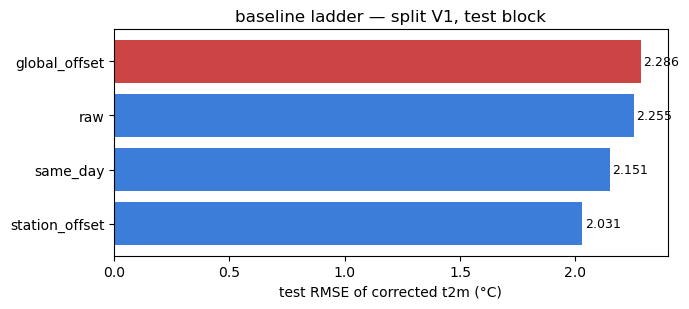

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.2))
tbl_sorted = tbl.sort_values("rmse")
bars = ax.barh(tbl_sorted.index, tbl_sorted.rmse, color=["#3b7dd8" if i else "#c44" for i in range(len(tbl_sorted))][::-1])
for y, v in enumerate(tbl_sorted.rmse):
    ax.text(v + 0.01, y, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlabel("test RMSE of corrected t2m (°C)"); ax.set_title(f"baseline ladder — split {common.SPLIT_V1.name}, test block")
plt.tight_layout(); plt.show()

## 3. Temporal stability and coverage

Two diagnostics. First, daily test-block RMSE, to establish whether the ranking is stable across days or driven by a single regime. Second, the coverage of the same-day scheme, which requires at least three pairs from the same station and local day before it can act, and is therefore unavailable in the early hours of each local day.

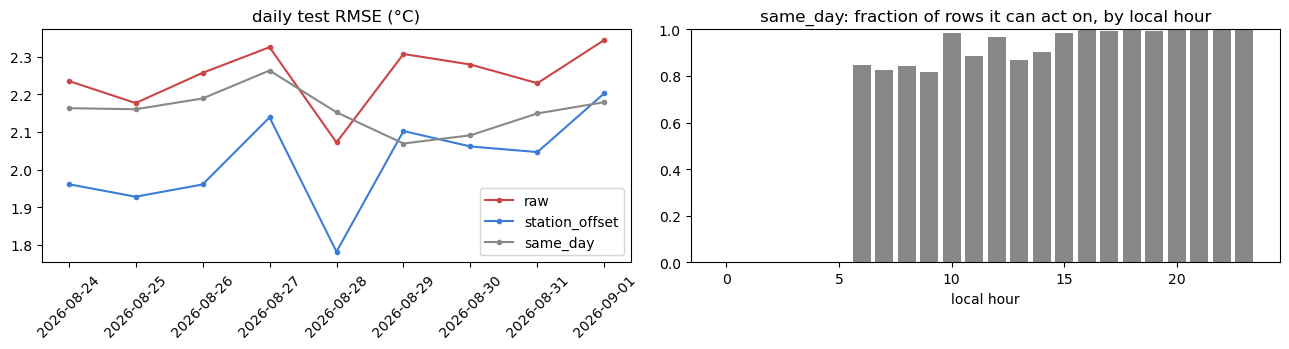

same_day acts on 66% of test rows overall


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
tm = (split == "test")
tw = w[tm].copy()
for col, c in [("raw","#c44"), ("station_offset","#3b7dd8"), ("same_day","#888")]:
    resid = (w.err_t2m - preds[col])[tm]
    daily = resid.groupby(tw.forecast_valid_time.dt.tz_convert("UTC").dt.date).apply(common.rmse)
    axes[0].plot(daily.index, daily.values, marker="o", ms=3, label=col, color=c)
axes[0].legend(); axes[0].set_title("daily test RMSE (°C)"); axes[0].tick_params(axis="x", rotation=45)

fires = (preds.same_day != 0)[tm]
rate = fires.groupby(tw.local_hour.round()).mean()
axes[1].bar(rate.index, rate.values, color="#888")
axes[1].set_title("same_day: fraction of rows it can act on, by local hour")
axes[1].set_xlabel("local hour"); axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()
print(f"same_day acts on {fires.mean():.0%} of test rows overall")

## Summary

Test-block values (split V1, n = 12,881) define the reference points for notebook 03:

| baseline | test RMSE (°C) |
|---|---|
| global_offset | 2.286 |
| raw | 2.255 |
| same_day | 2.151 |
| station_offset | 2.031 |

1. `station_offset` (2.031 °C) is the skill reference: a per-station constant estimated from three weeks of history and applied out of sample.
2. `same_day` (2.151 °C) is the deployment reference, being the method currently in production. It acts on 66% of test rows.
3. `global_offset` is worse than `raw` because the CONUS-wide mean error changed sign between the train and test periods.

A model that improves on `station_offset` in the test block, at full coverage, with a calibrated interval, meets the conditions for consideration as a replacement for the point correction in `bias.py`.